<a href="https://colab.research.google.com/github/mahim83/Deep-Learning-Assignments-certificates/blob/main/Assignment2_Implement_single_layer_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from urllib.request import urlopen

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data"

# Open the URL and read its content
with urlopen(url) as response:
    data = response.read().decode('utf-8')

# Print the first few lines to inspect the raw data
print("First 5 lines of raw data:")
for i, line in enumerate(data.splitlines()):
    if i < 5:
        print(line)
    else:
        break


First 5 lines of raw data:
1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.00,1
2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.00,1
3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.00,1
4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.00,1
5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.00,1


In [ ]:
X = []
y = []

# Iterate through each line of the decoded data, skipping the header if any (not present here based on inspection)
for line in data.splitlines():
    # Skip empty lines
    if not line.strip():
        continue

    # Split the line by comma
    parts = line.strip().split(',')

    # The dataset ID is the first element, features start from the second element
    # and the last element is the class label.
    # There are 9 features (index 1 to 9) and the target is index 10.

    try:
        # Convert features to floats
        features = [float(p) for p in parts[1:10]]
        # Convert target to int
        target = int(parts[10])

        X.append(features)
        y.append(target)
    except ValueError as e:
        print(f"Skipping line due to parsing error: {line} - {e}")
        continue


print("First 5 rows of features (X):")
for i, row in enumerate(X):
    if i < 5:
        print(row)
    else:
        break

print("\nFirst 5 target labels (y):")
for i, label in enumerate(y):
    if i < 5:
        print(label)
    else:
        break

First 5 rows of features (X):
[1.52101, 13.64, 4.49, 1.1, 71.78, 0.06, 8.75, 0.0, 0.0]
[1.51761, 13.89, 3.6, 1.36, 72.73, 0.48, 7.83, 0.0, 0.0]
[1.51618, 13.53, 3.55, 1.54, 72.99, 0.39, 7.78, 0.0, 0.0]
[1.51766, 13.21, 3.69, 1.29, 72.61, 0.57, 8.22, 0.0, 0.0]
[1.51742, 13.27, 3.62, 1.24, 73.08, 0.55, 8.07, 0.0, 0.0]

First 5 target labels (y):
1
1
1
1
1


In [ ]:
y_binary = []
for label in y:
    if label == 1:
        y_binary.append(1)
    else:
        y_binary.append(-1)

print("First 5 original target labels (y):")
for i, label in enumerate(y):
    if i < 5:
        print(label)
    else:
        break

print("\nFirst 5 binary target labels (y_binary):")
for i, label in enumerate(y_binary):
    if i < 5:
        print(label)
    else:
        break


First 5 original target labels (y):
1
1
1
1
1

First 5 binary target labels (y_binary):
1
1
1
1
1


In [ ]:
import random

# 1. Determine the number of features
num_features = len(X[0])

# 2. Initialize weights with small random numbers
weights = [random.uniform(-0.5, 0.5) for _ in range(num_features)]

# 3. Initialize bias with a small random number
bias = random.uniform(-0.5, 0.5)

print(f"Initialized weights: {weights}")
print(f"Initialized bias: {bias}")

Initialized weights: [-0.0018640655051338495, -0.2153669258618499, -0.13131078617394565, 0.20506335114442065, 0.44091302231008167, 0.0463536338094116, -0.14614579579111087, -0.062369364696483465, -0.4816145052840083]
Initialized bias: 0.30327111559616027


In [ ]:
def activate(weighted_sum):
    """Step activation function."""
    if weighted_sum >= 0:
        return 1
    else:
        return -1

def predict(x, weights, bias):
    """Calculates the prediction for a single feature vector."""
    weighted_sum = 0
    for i in range(len(x)):
        weighted_sum += x[i] * weights[i]
    weighted_sum += bias
    return activate(weighted_sum)

# Test the predict function with the first example from X
first_prediction = predict(X[0], weights, bias)
print(f"Prediction for the first sample: {first_prediction}")

Prediction for the first sample: 1


In [ ]:
learning_rate = 0.01
epochs = 100

print(f"Initial weights: {weights}")
print(f"Initial bias: {bias}")

for epoch in range(epochs):
    # Keep track of errors to see if the perceptron is learning
    errors = 0
    for i in range(len(X)): # Iterate through each sample
        x_i = X[i]
        y_i = y_binary[i]

        # Make a prediction
        prediction = predict(x_i, weights, bias)

        # Update weights and bias if misclassified
        if prediction != y_i:
            errors += 1
            # Update weights
            for j in range(len(weights)):
                weights[j] = weights[j] + learning_rate * y_i * x_i[j]
            # Update bias
            bias = bias + learning_rate * y_i
    # Optional: Print errors per epoch to observe learning progress
    # print(f"Epoch {epoch+1}/{epochs}, Errors: {errors}")

print(f"\nFinal weights after training: {weights}")
print(f"Final bias after training: {bias}")

Initial weights: [-0.0018640655051338495, -0.2153669258618499, -0.13131078617394565, 0.20506335114442065, 0.44091302231008167, 0.0463536338094116, -0.14614579579111087, -0.062369364696483465, -0.4816145052840083]
Initial bias: 0.30327111559616027

Final weights after training: [-0.011804165505133923, -1.5717669258618487, 0.6437892138260551, -0.44593664885557793, -0.3668869776899195, -0.05424636619058822, 1.156354204208891, -0.062369364696483465, -0.6016145052840062]
Final bias after training: 0.29327111559616026


In [ ]:
predictions = []
for x_i in X:
    predictions.append(predict(x_i, weights, bias))

correct_predictions = 0
for i in range(len(y_binary)):
    if predictions[i] == y_binary[i]:
        correct_predictions += 1

total_samples = len(X)
accuracy = correct_predictions / total_samples

print(f"Total samples: {total_samples}")
print(f"Correct predictions: {correct_predictions}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Total samples: 214
Correct predictions: 144
Accuracy: 67.29%


In [10]:
from urllib.request import urlopen

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data"

# Open the URL and read its content
with urlopen(url) as response:
    data = response.read().decode('utf-8')

# Print the first few lines to inspect the raw data
print("First 5 lines of raw data:")
for i, line in enumerate(data.splitlines()):
    if i < 5:
        print(line)
    else:
        break

First 5 lines of raw data:
1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.00,1
2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.00,1
3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.00,1
4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.00,1
5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.00,1


In [11]:
X = []
y = []

# Iterate through each line of the decoded data, skipping the header if any (not present here based on inspection)
for line in data.splitlines():
    # Skip empty lines
    if not line.strip():
        continue

    # Split the line by comma
    parts = line.strip().split(',')

    # The dataset ID is the first element, features start from the second element
    # and the last element is the class label.
    # There are 9 features (index 1 to 9) and the target is index 10.

    try:
        # Convert features to floats
        features = [float(p) for p in parts[1:10]]
        # Convert target to int
        target = int(parts[10])

        X.append(features)
        y.append(target)
    except ValueError as e:
        print(f"Skipping line due to parsing error: {line} - {e}")
        continue


print("First 5 rows of features (X):")
for i, row in enumerate(X):
    if i < 5:
        print(row)
    else:
        break

print("\nFirst 5 target labels (y):")
for i, label in enumerate(y):
    if i < 5:
        print(label)
    else:
        break

First 5 rows of features (X):
[1.52101, 13.64, 4.49, 1.1, 71.78, 0.06, 8.75, 0.0, 0.0]
[1.51761, 13.89, 3.6, 1.36, 72.73, 0.48, 7.83, 0.0, 0.0]
[1.51618, 13.53, 3.55, 1.54, 72.99, 0.39, 7.78, 0.0, 0.0]
[1.51766, 13.21, 3.69, 1.29, 72.61, 0.57, 8.22, 0.0, 0.0]
[1.51742, 13.27, 3.62, 1.24, 73.08, 0.55, 8.07, 0.0, 0.0]

First 5 target labels (y):
1
1
1
1
1


In [12]:
y_binary = []
for label in y:
    if label == 1:
        y_binary.append(1)
    else:
        y_binary.append(-1)

print("First 5 original target labels (y):")
for i, label in enumerate(y):
    if i < 5:
        print(label)
    else:
        break

print("\nFirst 5 binary target labels (y_binary):")
for i, label in enumerate(y_binary):
    if i < 5:
        print(label)
    else:
        break


First 5 original target labels (y):
1
1
1
1
1

First 5 binary target labels (y_binary):
1
1
1
1
1


In [13]:
import random

# 1. Determine the number of features
num_features = len(X[0])

# 2. Initialize weights with small random numbers
weights = [random.uniform(-0.5, 0.5) for _ in range(num_features)]

# 3. Initialize bias with a small random number
bias = random.uniform(-0.5, 0.5)

print(f"Initialized weights: {weights}")
print(f"Initialized bias: {bias}")

Initialized weights: [0.41093268985841447, -0.48893131143603663, 0.09580434791896719, -0.218407842759077, 0.3071545180166416, -0.4861853635229003, 0.268081133456629, -0.11792282384871733, -0.4104245364894936]
Initialized bias: 0.4072734901036673


In [14]:
def activate(weighted_sum):
    """Step activation function."""
    if weighted_sum >= 0:
        return 1
    else:
        return -1

def predict(x, weights, bias):
    """Calculates the prediction for a single feature vector."""
    weighted_sum = 0
    for i in range(len(x)):
        weighted_sum += x[i] * weights[i]
    weighted_sum += bias
    return activate(weighted_sum)

# Test the predict function with the first example from X
first_prediction = predict(X[0], weights, bias)
print(f"Prediction for the first sample: {first_prediction}")

Prediction for the first sample: 1


In [15]:
learning_rate = 0.01
epochs = 100

print(f"Initial weights: {weights}")
print(f"Initial bias: {bias}")

for epoch in range(epochs):
    # Keep track of errors to see if the perceptron is learning
    errors = 0
    for i in range(len(X)): # Iterate through each sample
        x_i = X[i]
        y_i = y_binary[i]

        # Make a prediction
        prediction = predict(x_i, weights, bias)

        # Update weights and bias if misclassified
        if prediction != y_i:
            errors += 1
            # Update weights
            for j in range(len(weights)):
                weights[j] = weights[j] + learning_rate * y_i * x_i[j]
            # Update bias
            bias = bias + learning_rate * y_i
    # Optional: Print errors per epoch to observe learning progress
    # print(f"Epoch {epoch+1}/{epochs}, Errors: {errors}")

print(f"\nFinal weights after training: {weights}")
print(f"Final bias after training: {bias}")

Initial weights: [0.41093268985841447, -0.48893131143603663, 0.09580434791896719, -0.218407842759077, 0.3071545180166416, -0.4861853635229003, 0.268081133456629, -0.11792282384871733, -0.4104245364894936]
Initial bias: 0.4072734901036673

Final weights after training: [0.4009925898584161, -1.8453313114360355, 0.8709043479189709, -0.8694078427590732, -0.5006454819833596, -0.5867853635229004, 1.5705811334566313, -0.11792282384871733, -0.5304245364894915]
Final bias after training: 0.3972734901036673


In [16]:
predictions = []
for x_i in X:
    predictions.append(predict(x_i, weights, bias))

correct_predictions = 0
for i in range(len(y_binary)):
    if predictions[i] == y_binary[i]:
        correct_predictions += 1

total_samples = len(X)
accuracy = correct_predictions / total_samples

print(f"Total samples: {total_samples}")
print(f"Correct predictions: {correct_predictions}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Total samples: 214
Correct predictions: 144
Accuracy: 67.29%


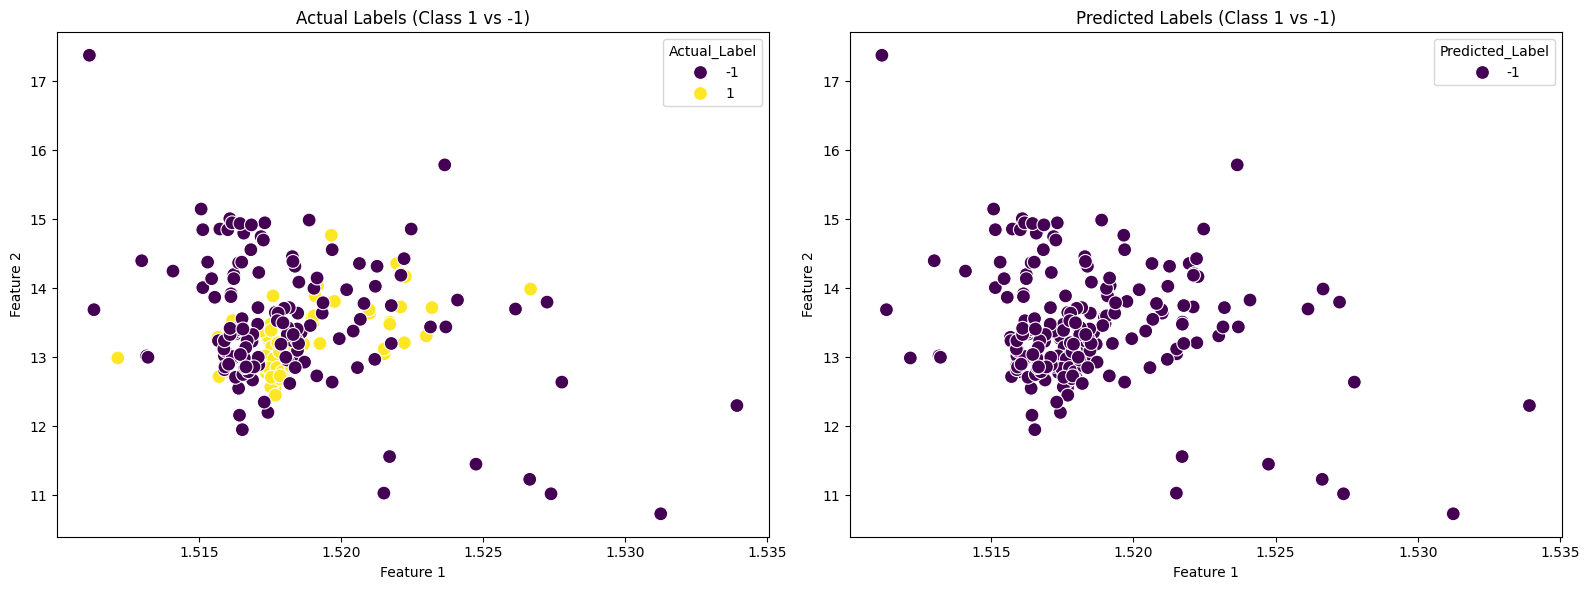

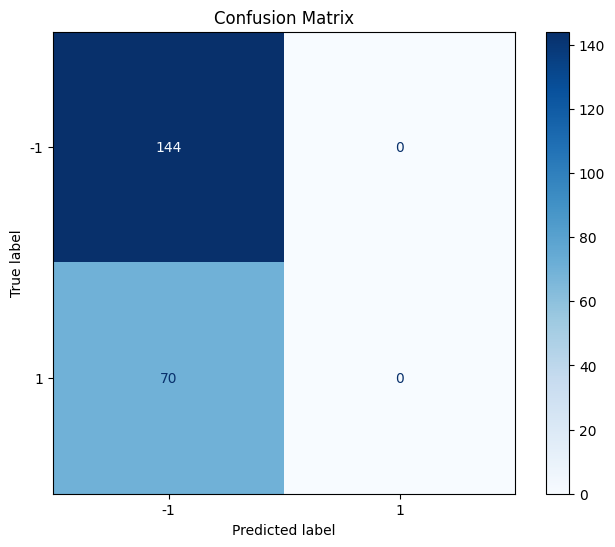

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create a DataFrame from features and labels
df = pd.DataFrame(X)

# Assuming there are at least two features for visualization
# Using the first two features for a 2D scatter plot
feature_names = [f'Feature_{i+1}' for i in range(len(X[0]))]
df.columns = feature_names

df['Actual_Label'] = y_binary
df['Predicted_Label'] = predictions

# Visualize Actual vs. Predicted Labels based on two features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x='Feature_1', y='Feature_2', hue='Actual_Label', data=df, ax=axes[0], palette='viridis', s=100)
axes[0].set_title('Actual Labels (Class 1 vs -1)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

sns.scatterplot(x='Feature_1', y='Feature_2', hue='Predicted_Label', data=df, ax=axes[1], palette='viridis', s=100)
axes[1].set_title('Predicted Labels (Class 1 vs -1)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# Calculate and display the confusion matrix
cm = confusion_matrix(y_binary, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 1])
cmd.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix')
plt.show()